In [1]:
# ════════════════════════════════════════════════════════
# CELL 1 — Setup Paths (NO COPYING / DISK OPTIMIZED)
# ════════════════════════════════════════════════════════
import os

# 1. Define the read-only input paths from your attached datasets
CROPS_INPUT = '/kaggle/input/datasets/saisandeepn/deep-fashion-crops'
CAPTIONS_INPUT = '/kaggle/input/datasets/khsudhir/captions'

# 2. Define the working directory for Notebook 3's NEW outputs
PROJ = '/kaggle/working'

# We only create folders for the actual files Notebook 3 will generate
DIRS = [
    f'{PROJ}/checkpoints', # For saving the trained CLIP model
    f'{PROJ}/index',       # For saving the vector database (HNSWlib)
    f'{PROJ}/results',     # For saving evaluation metrics
]

for d in DIRS:
    os.makedirs(d, exist_ok=True)

print("✅ Paths configured securely (No files copied to save disk space!)")
print(f"Crops dataset   : {CROPS_INPUT}")
print(f"Captions dataset: {CAPTIONS_INPUT}")
print("\nOutput folders created:")
for d in DIRS:
    print(f" -> {d}")

# Quick sanity check to make sure it sees your files
print("\n--- Sanity Check ---")
print("CSV found?", os.path.exists(f"{CROPS_INPUT}/dataset_index.csv"))
print("Captions found?", os.path.exists(f"{CAPTIONS_INPUT}/captions/captions.json"))

✅ Paths configured securely (No files copied to save disk space!)
Crops dataset   : /kaggle/input/datasets/saisandeepn/deep-fashion-crops
Captions dataset: /kaggle/input/datasets/khsudhir/captions

Output folders created:
 -> /kaggle/working/checkpoints
 -> /kaggle/working/index
 -> /kaggle/working/results

--- Sanity Check ---
CSV found? True
Captions found? True


In [3]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

!pip install open-clip-torch -q

Device: cuda
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00


In [4]:
import torch
import numpy as np
import random

# Your team's roll numbers
SEEDS = [546, 574, 580, 598]

# CHANGE THIS to 'A', 'B', or 'C' depending on which experiment you are running
CONDITION = 'C' 

print(f"--- SETTING UP FOR CONDITION: {CONDITION} ---")

if CONDITION == 'A':
    ALPHA = 1.0
    FINE_TUNE = False
elif CONDITION == 'B':
    ALPHA = 0.5  # You can choose any value in [0, 1] for B and C
    FINE_TUNE = False
elif CONDITION == 'C':
    ALPHA = 0.5  # Make sure this matches Condition B
    FINE_TUNE = True

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

--- SETTING UP FOR CONDITION: C ---


In [5]:
# ════════════════════════════════════════════════════════
# CELL 2 — Dataset: same-item positive pairs (PATH FIXED)
# ════════════════════════════════════════════════════════
from torch.utils.data import Dataset
from PIL import Image
import random

class FashionPairDataset(Dataset):
    """
    Each __getitem__ returns:
      anchor_img  : tensor  — one crop of item X
      positive_img: tensor  — different crop of same item X
      item_id     : str     — for reference / logging
    Uses GT crops (train split only).
    """
    def __init__(self, train_df, crop_meta, transform):
        self.transform = transform
        self.crop_meta = crop_meta

        # Group by item_id, keep items that have ≥ 2 images
        # (need at least 2 to form a pair)
        grouped = train_df.groupby('item_id')['image_path'].apply(list)
        self.items = {iid: paths 
                      for iid, paths in grouped.items() 
                      if len(paths) >= 2}
        self.item_list = list(self.items.keys())
        print(f"Items with ≥2 images (usable for pairs): {len(self.item_list):,}")

    def __len__(self):
        return len(self.item_list)

    def __getitem__(self, idx):
        item_id = self.item_list[idx]
        path_a, path_b = random.sample(self.items[item_id], 2)

        # 1. Get the old paths from the meta dict
        old_crop_a = self.crop_meta.get(path_a, path_a)
        old_crop_b = self.crop_meta.get(path_b, path_b)

        # 2. >>> CRITICAL FIX: Translate to Kaggle Input <<<
        crop_a = old_crop_a.replace('/kaggle/working', CROPS_INPUT)
        crop_b = old_crop_b.replace('/kaggle/working', CROPS_INPUT)

        # 3. Open images (with a safety net to prevent training crashes)
        try:
            img_a = Image.open(crop_a).convert('RGB')
            img_b = Image.open(crop_b).convert('RGB')
        except Exception as e:
            # If an image is somehow missing or corrupted, quietly try the next one
            return self.__getitem__((idx + 1) % len(self.item_list))

        return self.transform(img_a), self.transform(img_b), item_id

In [6]:
# ════════════════════════════════════════════════════════
# CELL 3 — Load CLIP + selective unfreeze (PATH & LOGIC FIXED)
# ════════════════════════════════════════════════════════
import open_clip
import json
import pandas as pd
from torch.utils.data import DataLoader

# Assuming 'device' was defined in Cell 1 or 2 (usually: device = "cuda" if torch.cuda.is_available() else "cpu")
device = "cuda" if torch.cuda.is_available() else "cpu"

model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)
model = model.to(device)

# Step 1: Freeze everything by default
for p in model.parameters():
    p.requires_grad = False

# Step 2: Unfreeze conditionally based on your MASTER SWITCH
if FINE_TUNE:
    print(f"--- Condition {CONDITION}: Unfreezing Vision blocks for training ---")
    vision_blocks = model.visual.transformer.resblocks
    total_blocks  = len(vision_blocks)
    UNFREEZE_N    = 4   # minimum per PDF

    print(f"Vision transformer blocks total: {total_blocks}")
    print(f"Unfreezing last {UNFREEZE_N} blocks")

    for block in vision_blocks[total_blocks - UNFREEZE_N:]:
        for p in block.parameters():
            p.requires_grad = True

    # unfreeze the final vision projection
    if hasattr(model.visual, 'proj') and model.visual.proj is not None:
        model.visual.proj.requires_grad = True
else:
    print(f"--- Condition {CONDITION}: Model remains completely frozen (Zero-shot) ---")

# Verify what is actually trainable
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")
print("Text encoder frozen: ✓")

# Step 3: Build dataloader (Using correct Kaggle Input paths!)
df        = pd.read_csv(f'{CROPS_INPUT}/dataset_index.csv')
crop_meta = json.load(open(f'{CROPS_INPUT}/crop_meta_gt.json'))
train_df  = df[df['split'] == 'train'].reset_index(drop=True)

dataset = FashionPairDataset(train_df, crop_meta, preprocess)

# Note: If you ever get an "Out of Memory" (OOM) error here, lower batch_size to 32.
loader  = DataLoader(
    dataset, 
    batch_size=64, 
    shuffle=True,
    num_workers=2, 
    pin_memory=True, 
    drop_last=True
)
print(f"Batches per epoch: {len(loader):,}")

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


--- Condition C: Unfreezing Vision blocks for training ---
Vision transformer blocks total: 12
Unfreezing last 4 blocks
Trainable: 28,744,704 / 151,277,313  (19.0%)
Text encoder frozen: ✓
Items with ≥2 images (usable for pairs): 3,985
Batches per epoch: 62


In [7]:
# ════════════════════════════════════════════════════════
# CELL 4 — NT-Xent contrastive loss (IMPORT FIXED)
# ════════════════════════════════════════════════════════
import torch
import torch.nn.functional as F

def nt_xent_loss(emb_a, emb_b, temperature=0.07):
    """
    emb_a, emb_b : (N, D) L2-normalised embeddings
    Returns scalar loss.
    """
    N = emb_a.shape[0]

    # Concatenate: first N rows = anchors, last N rows = positives
    z   = torch.cat([emb_a, emb_b], dim=0)                   # (2N, D)
    sim = (z @ z.T) / temperature                            # (2N, 2N)

    # Remove self-similarity (diagonal = -inf so softmax ignores it)
    mask = torch.eye(2 * N, dtype=torch.bool, device=sim.device)
    sim.masked_fill_(mask, float('-inf'))

    # For row i (anchor i), positive is at row i+N
    # For row i+N (positive i), positive is at row i
    labels = torch.cat([
        torch.arange(N, 2 * N),
        torch.arange(0, N)
    ]).to(sim.device) # Good practice to match device dynamically

    return F.cross_entropy(sim, labels)


Starting Training for Seed: 546 (Condition C)
Loading a fresh base CLIP model...


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Seed 546 | Epoch 1/5:   0%|          | 0/62 [00:00<?, ?it/s]

Seed 546 | Epoch 1 | avg loss: 1.2995 | best so far: inf
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed546_best.pt


Seed 546 | Epoch 2/5:   0%|          | 0/62 [00:00<?, ?it/s]

...

Seed 546 | Epoch 3 | avg loss: 0.4842 | best so far: 0.5992
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed546_best.pt


Seed 546 | Epoch 4/5:   0%|          | 0/62 [00:00<?, ?it/s]

Seed 546 | Epoch 4 | avg loss: 0.4349 | best so far: 0.4842
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed546_best.pt


Seed 546 | Epoch 5/5:   0%|          | 0/62 [00:00<?, ?it/s]

Seed 546 | Epoch 5 | avg loss: 0.4131 | best so far: 0.4349
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed546_best.pt
Last checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed546_last.pt


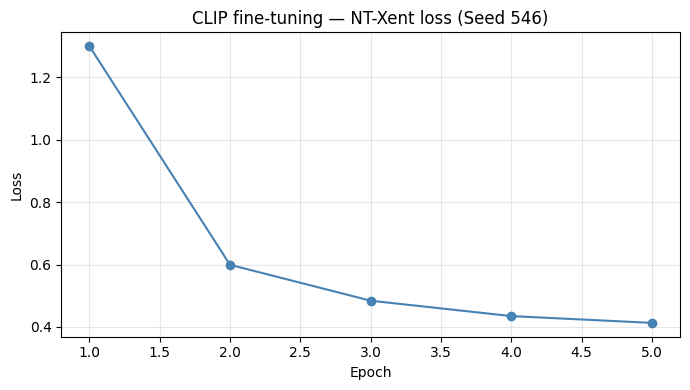


Starting Training for Seed: 574 (Condition C)
Loading a fresh base CLIP model...


Seed 574 | Epoch 1/5:   0%|          | 0/62 [00:00<?, ?it/s]

Seed 574 | Epoch 1 | avg loss: 1.2848 | best so far: inf
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed574_best.pt


Seed 574 | Epoch 2/5:   0%|          | 0/62 [00:00<?, ?it/s]

Seed 574 | Epoch 2 | avg loss: 0.6166 | best so far: 1.2848
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed574_best.pt


...

Seed 574 | Epoch 4/5:   0%|          | 0/62 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bfb35989f80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bfb35989f80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Seed 574 | Epoch 4 | avg loss: 0.4210 | best so far: 0.4853
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed574_best.pt


Seed 574 | Epoch 5/5:   0%|          | 0/62 [00:00<?, ?it/s]

Seed 574 | Epoch 5 | avg loss: 0.3788 | best so far: 0.4210
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed574_best.pt
Last checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed574_last.pt


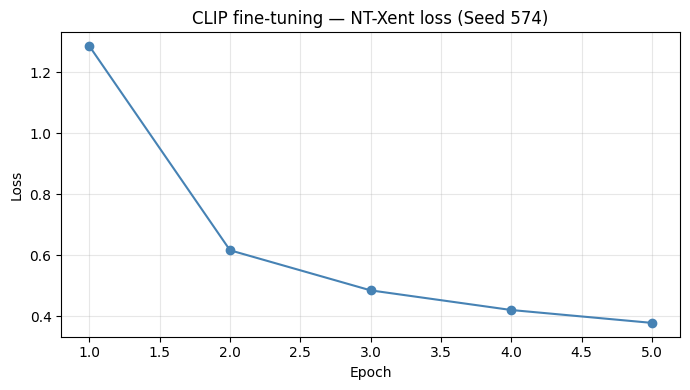


Starting Training for Seed: 580 (Condition C)
Loading a fresh base CLIP model...


Seed 580 | Epoch 1/5:   0%|          | 0/62 [00:00<?, ?it/s]

Seed 580 | Epoch 1 | avg loss: 1.3288 | best so far: inf
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed580_best.pt


Seed 580 | Epoch 2/5:   0%|          | 0/62 [00:00<?, ?it/s]

Seed 580 | Epoch 2 | avg loss: 0.6038 | best so far: 1.3288
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed580_best.pt


...

Seed 580 | Epoch 3 | avg loss: 0.4838 | best so far: 0.6038
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed580_best.pt


Seed 580 | Epoch 4/5:   0%|          | 0/62 [00:00<?, ?it/s]

Seed 580 | Epoch 4 | avg loss: 0.4127 | best so far: 0.4838
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed580_best.pt


Seed 580 | Epoch 5/5:   0%|          | 0/62 [00:00<?, ?it/s]

Seed 580 | Epoch 5 | avg loss: 0.3896 | best so far: 0.4127
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed580_best.pt
Last checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed580_last.pt


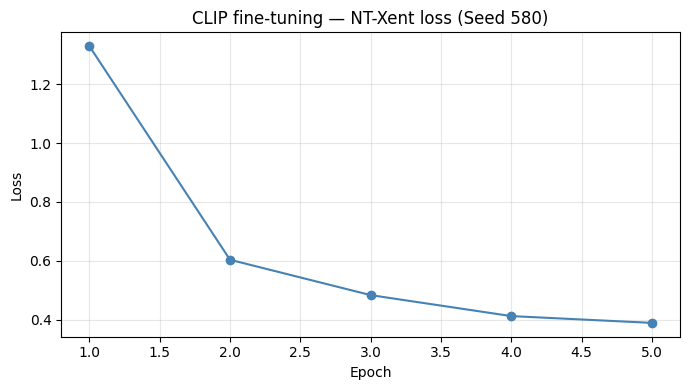


Starting Training for Seed: 598 (Condition C)
Loading a fresh base CLIP model...


Seed 598 | Epoch 1/5:   0%|          | 0/62 [00:00<?, ?it/s]

Seed 598 | Epoch 1 | avg loss: 1.3551 | best so far: inf
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed598_best.pt


Seed 598 | Epoch 2/5:   0%|          | 0/62 [00:00<?, ?it/s]

Seed 598 | Epoch 2 | avg loss: 0.6235 | best so far: 1.3551
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed598_best.pt


...

Seed 598 | Epoch 3 | avg loss: 0.4928 | best so far: 0.6235
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed598_best.pt


Seed 598 | Epoch 4/5:   0%|          | 0/62 [00:00<?, ?it/s]

Seed 598 | Epoch 4 | avg loss: 0.4246 | best so far: 0.4928
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed598_best.pt


Seed 598 | Epoch 5/5:   0%|          | 0/62 [00:00<?, ?it/s]

Seed 598 | Epoch 5 | avg loss: 0.4103 | best so far: 0.4246
  ✓ Best checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed598_best.pt
Last checkpoint saved → /kaggle/working/checkpoints/clip_ft_C_seed598_last.pt


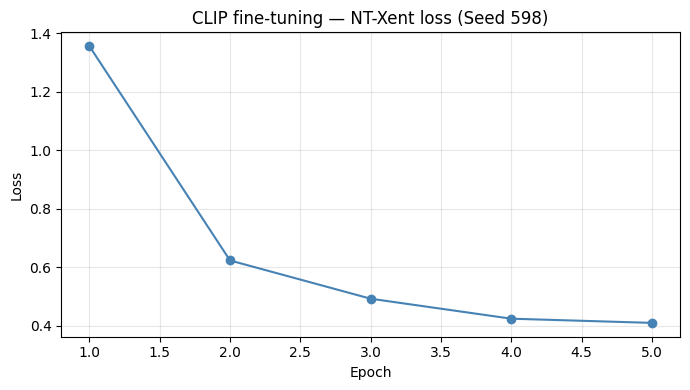

In [8]:
# ════════════════════════════════════════════════════════
# CELL 5 — Training loop (MULTI-SEED & STATE FIXED)
# ════════════════════════════════════════════════════════
from tqdm.auto import tqdm  # Auto chooses the cleanest UI
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import open_clip

EPOCHS    = 5       # increase to 10+ if on A100
LR        = 1e-5
CKPT_DIR  = f'{PROJ}/checkpoints'
UNFREEZE_N = 4      # Must match Cell 3

# Only run training if we are doing Condition C
if FINE_TUNE:
    for seed in SEEDS:
        print(f"\n{'='*50}")
        print(f"Starting Training for Seed: {seed} (Condition {CONDITION})")
        print(f"{'='*50}")
        
        # 1. Lock in the randomness for this specific run
        set_seed(seed)
        
        # 2. >>> CRITICAL FIX: FRESH MODEL INITIALIZATION <<<
        # We MUST reload a clean base model for every seed so they don't share memory/history!
        print("Loading a fresh base CLIP model...")
        model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
        model = model.to(device)

        # Re-apply the freezing/unfreezing rules exactly like Cell 3
        for p in model.parameters():
            p.requires_grad = False

        vision_blocks = model.visual.transformer.resblocks
        total_blocks  = len(vision_blocks)
        
        for block in vision_blocks[total_blocks - UNFREEZE_N:]:
            for p in block.parameters():
                p.requires_grad = True

        if hasattr(model.visual, 'proj') and model.visual.proj is not None:
            model.visual.proj.requires_grad = True
        
        # 3. Setup distinct filenames to prevent overwriting
        BEST_CKPT = f'{CKPT_DIR}/clip_ft_{CONDITION}_seed{seed}_best.pt'
        LAST_CKPT = f'{CKPT_DIR}/clip_ft_{CONDITION}_seed{seed}_last.pt'

        optimizer = torch.optim.AdamW(
            [p for p in model.parameters() if p.requires_grad],
            lr=LR, weight_decay=0.01
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS * len(loader)
        )

        best_loss = float('inf')
        history   = []
        model.train()

        # 4. The actual training loop
        for epoch in range(EPOCHS):
            epoch_loss = 0.0
            pbar = tqdm(loader, desc=f"Seed {seed} | Epoch {epoch+1}/{EPOCHS}")

            for anchor_imgs, pos_imgs, _ in pbar:
                anchor_imgs = anchor_imgs.to(device)
                pos_imgs    = pos_imgs.to(device)

                emb_a = F.normalize(model.encode_image(anchor_imgs), dim=-1)
                emb_b = F.normalize(model.encode_image(pos_imgs),    dim=-1)

                loss = nt_xent_loss(emb_a, emb_b)

                optimizer.zero_grad()
                loss.backward()
                
                # Gradient clipping prevents exploding gradients
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], max_norm=1.0
                )
                optimizer.step()
                scheduler.step()

                epoch_loss += loss.item()
                pbar.set_postfix(loss=f"{loss.item():.4f}")

            avg_loss = epoch_loss / len(loader)
            history.append(avg_loss)
            print(f"Seed {seed} | Epoch {epoch+1} | avg loss: {avg_loss:.4f} | best so far: {best_loss:.4f}")

            if avg_loss < best_loss:
                best_loss = avg_loss
                torch.save(model.state_dict(), BEST_CKPT)
                print(f"  ✓ Best checkpoint saved → {BEST_CKPT}")

        torch.save(model.state_dict(), LAST_CKPT)
        print(f"Last checkpoint saved → {LAST_CKPT}")

        # 5. Loss curve plotting
        plt.figure(figsize=(7, 4))
        plt.plot(range(1, EPOCHS + 1), history, marker='o', color='steelblue')
        plt.title(f'CLIP fine-tuning — NT-Xent loss (Seed {seed})')
        plt.xlabel('Epoch'); plt.ylabel('Loss')
        plt.grid(alpha=0.3); plt.tight_layout()
        plt.savefig(f'{CKPT_DIR}/loss_curve_seed{seed}.png', dpi=150)
        plt.show()
        
        # 6. >>> CRITICAL VRAM FIX <<<
        # Flush the GPU cache so the next seed doesn't trigger an Out of Memory error
        del model, optimizer, scheduler, emb_a, emb_b, loss
        torch.cuda.empty_cache()

else:
    print(f"\nCondition {CONDITION} selected. FINE_TUNE is False. Skipping the training loop.")

In [9]:
# ════════════════════════════════════════════════════════
# CELL 6 — Export Trained Models (Clean Zip)
# ════════════════════════════════════════════════════════
import os
import zipfile

# Name of the final export file
zip_name = '/kaggle/working/safe_models.zip'
ckpt_dir = '/kaggle/working/checkpoints'

print("Bundling all trained models and loss curves...")

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    if os.path.exists(ckpt_dir):
        # Grab every single model and graph generated in the checkpoints folder
        for file in os.listdir(ckpt_dir):
            file_path = os.path.join(ckpt_dir, file)
            # Add the file to the zip, keeping the 'checkpoints/' structure inside
            zf.write(file_path, f'checkpoints/{file}')
            print(f"  ✓ Added: {file}")
    else:
        print("❌ Error: Checkpoints directory not found. Did the training finish?")

# Calculate the final file size
if os.path.exists(zip_name):
    final_size = os.path.getsize(zip_name) / 1e6
    print(f"\n✅ Success! Created 'safe_models.zip' ({final_size:.1f} MB)")
    print("Download this file from the right sidebar!")

Bundling all trained models and loss curves...
  ✓ Added: loss_curve_seed580.png
  ✓ Added: clip_ft_C_seed574_best.pt
  ✓ Added: loss_curve_seed598.png
  ✓ Added: clip_ft_C_seed574_last.pt
  ✓ Added: clip_ft_C_seed598_best.pt
  ✓ Added: clip_ft_C_seed546_last.pt
  ✓ Added: clip_ft_C_seed546_best.pt
  ✓ Added: clip_ft_C_seed580_best.pt
  ✓ Added: clip_ft_C_seed598_last.pt
  ✓ Added: loss_curve_seed546.png
  ✓ Added: clip_ft_C_seed580_last.pt
  ✓ Added: loss_curve_seed574.png

✅ Success! Created 'safe_models.zip' (3443.1 MB)
Download this file from the right sidebar!
